### Imports & seeds

In [42]:
import numpy as np
import pandas as pd
import re
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from itertools import combinations

np.random.seed(42)
tf.random.set_seed(42)


### Load data

In [43]:
file_path = "data\\new_data\\Shanghai_T1DM_merged.xlsx"  
df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Patient_ID", "Date"]).reset_index(drop=True)

df.head()


,Date,CGM (mg / dl),CBG (mg / dl),Blood Ketone (mmol / L),Dietary intake,饮食,Insulin dose - s.c.,Non-insulin hypoglycemic agents,"CSII - bolus insulin (Novolin R, IU)","CSII - basal insulin (Novolin R, IU / H)",Insulin dose - i.v.,Patient_ID
0,2021-07-30 16:43:00,113.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,1001_0_20210730
1,2021-07-30 16:58:00,124.2,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,1001_0_20210730
2,2021-07-30 17:13:00,129.6,NaN,NaN,data not available,未记录,NaN,NaN,NaN,NaN,NaN,1001_0_20210730
3,2021-07-30 17:28:00,142.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1001_0_20210730
4,2021-07-30 17:43:00,156.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1001_0_20210730


### Clean numeric columns

In [44]:
def extract_numeric(x):
    if pd.isna(x):
        return 0.0
    if isinstance(x, (int, float)):
        return float(x)
    m = re.search(r"[\d\.]+", str(x))
    return float(m.group()) if m else 0.0


NUMERIC_COLS = [
    "CGM (mg / dl)",
    "CBG (mg / dl)",
    "Blood Ketone (mmol / L)",
    "Insulin dose - s.c.",
    "CSII - bolus insulin (Novolin R, IU)",
    "CSII - basal insulin (Novolin R, IU / H)",
    "Insulin dose - i.v."
]

for col in NUMERIC_COLS:
    df[col] = df[col].apply(extract_numeric)

df[NUMERIC_COLS].describe()


,CGM (mg / dl),CBG (mg / dl),Blood Ketone (mmol / L),Insulin dose - s.c.,"CSII - bolus insulin (Novolin R, IU)","CSII - basal insulin (Novolin R, IU / H)",Insulin dose - i.v.
count,4368.000000,4368.000000,4368.0,4368.000000,4368.000000,4368.000000,4368.0
mean,188.489835,5.848764,0.0,0.269460,0.035027,0.004579,0.0
std,74.547343,36.688940,0.0,1.538592,0.462379,0.047150,0.0
min,39.600000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
25%,127.800000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
50%,190.800000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
75%,243.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
max,475.200000,396.000000,0.0,16.000000,10.000000,0.600000,0.0


### Feature list

In [45]:
TARGET = "CGM (mg / dl)"

ALL_FEATURES = [
    "CGM (mg / dl)",
    "CBG (mg / dl)",
    "Blood Ketone (mmol / L)",
    "Insulin dose - s.c.",
    "CSII - bolus insulin (Novolin R, IU)",
    "CSII - basal insulin (Novolin R, IU / H)",
    "Insulin dose - i.v."
]


### Sequence builder

In [46]:
def make_sequences(data, target_idx, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback, target_idx])
    return np.array(X), np.array(y)


### LSTM / GRU trainer

In [47]:
def train_rnn(
    df,
    features,
    model_type="LSTM",
    lookback=12,
    epochs=30,
    batch_size=32
):
    data = df[features].values

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    target_idx = features.index(TARGET)

    X, y = make_sequences(data_scaled, target_idx, lookback)

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = Sequential()
    if model_type == "LSTM":
        model.add(LSTM(64, input_shape=(lookback, X.shape[2])))
    else:
        model.add(GRU(64, input_shape=(lookback, X.shape[2])))

    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(patience=5, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0,
        shuffle=False
    )

    y_pred = model.predict(X_test, verbose=0)

    X_last = X_test[:, -1, :-1]

    y_pred_real = scaler.inverse_transform(
        np.hstack([X_last, y_pred])
    )[:, -1]

    y_test_real = scaler.inverse_transform(
        np.hstack([X_last, y_test.reshape(-1,1)])
    )[:, -1]

    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    return rmse


### Baseline run

In [48]:
baseline_lstm = train_rnn(df, ALL_FEATURES, "LSTM")
baseline_gru  = train_rnn(df, ALL_FEATURES, "GRU")

baseline_lstm, baseline_gru


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(np.float64(0.017233487976199235), np.float64(0.016155948136577697))

### Feature extrication search

In [49]:
results = []

for r in range(len(ALL_FEATURES), 1, -1):
    for subset in combinations(ALL_FEATURES, r):

        if TARGET not in subset:
            continue

        rmse = train_rnn(df, list(subset), model_type="GRU")

        results.append({
            "features": subset,
            "rmse": rmse
        })

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df.head(10)

C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a

,features,rmse
0,"(CGM (mg / dl), CBG (mg / dl), Blood Ketone (m...",0.009010
1,"(CGM (mg / dl), CBG (mg / dl), Blood Ketone (m...",0.009614
2,"(CGM (mg / dl), CBG (mg / dl), Blood Ketone (m...",0.009660
3,"(CGM (mg / dl), CBG (mg / dl), Blood Ketone (m...",0.009688
4,"(CGM (mg / dl), CBG (mg / dl), CSII - basal in...",0.009716
5,"(CGM (mg / dl), Blood Ketone (mmol / L), Insul...",0.009954
6,"(CGM (mg / dl), CSII - bolus insulin (Novolin ...",0.009955
7,"(CGM (mg / dl), Blood Ketone (mmol / L), CSII ...",0.010012
8,"(CGM (mg / dl), Blood Ketone (mmol / L), CSII ...",0.010036
9,"(CGM (mg / dl), CBG (mg / dl), Insulin dose - ...",0.010064


### Lookback tuning

In [50]:
best_features = list(results_df.iloc[0]["features"])

for lb in [6, 12, 24, 36]:
    rmse = train_rnn(df, best_features, "GRU", lookback=lb)
    print(f"Lookback {lb}: RMSE = {rmse:.2f} mg/dL")


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Lookback 6: RMSE = 0.01 mg/dL


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Lookback 12: RMSE = 0.01 mg/dL


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Lookback 24: RMSE = 0.01 mg/dL


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Lookback 36: RMSE = 0.01 mg/dL


### Regularized model

In [51]:
def train_regularized(df, features, lookback=24):
    data = df[features].values
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    target_idx = features.index(TARGET)
    X, y = make_sequences(data_scaled, target_idx, lookback)

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = Sequential([
        GRU(64, return_sequences=True),
        Dropout(0.3),
        GRU(32),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

    y_pred = model.predict(X_test, verbose=0)

    X_last = X_test[:, -1, :-1]
    y_pred_real = scaler.inverse_transform(
        np.hstack([X_last, y_pred])
    )[:, -1]

    y_test_real = scaler.inverse_transform(
        np.hstack([X_last, y_test.reshape(-1,1)])
    )[:, -1]

    return np.sqrt(mean_squared_error(y_test_real, y_pred_real))


### Final best score

In [52]:
final_rmse = train_regularized(df, best_features)
print("Final GRU RMSE:", final_rmse, "mg/dL")


Final GRU RMSE: 0.009907332253348992 mg/dL


### HMM

In [53]:
from hmmlearn.hmm import GaussianHMM

states = pd.cut(
    df[TARGET],
    bins=[0, 70, 180, 500],
    labels=[0,1,2]
).astype(int)

hmm = GaussianHMM(n_components=3, covariance_type="diag", n_iter=100)
hmm.fit(states.values.reshape(-1,1))

pred_states = hmm.predict(states.values.reshape(-1,1))
accuracy = np.mean(pred_states == states.values)

accuracy


np.float64(0.21085164835164835)

In [54]:
def get_model_predictions(df, features, model_type="GRU", lookback=24):
    data = df[features].values
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)
    target_idx = features.index(TARGET)
    
    X, y = make_sequences(data_scaled, target_idx, lookback)
    split = int(0.8 * len(X))
    X_test, y_test = X[split:], y[split:]

    # Rebuild/Train model (simplified for matrix generation)
    model = Sequential([
        GRU(64, input_shape=(lookback, X.shape[2])) if model_type=="GRU" else LSTM(64, input_shape=(lookback, X.shape[2])),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X[:split], y[:split], epochs=10, batch_size=64, verbose=0)
    
    # Predict and Inverse Scale
    y_pred = model.predict(X_test, verbose=0)
    X_last = X_test[:, -1, :-1]
    y_pred_real = scaler.inverse_transform(np.hstack([X_last, y_pred]))[:, -1]
    y_test_real = scaler.inverse_transform(np.hstack([X_last, y_test.reshape(-1,1)]))[:, -1]
    
    return y_test_real, y_pred_real

# Get actual data for the matrix
y_true, gru_preds = get_model_predictions(df, best_features, "GRU")
_, lstm_preds = get_model_predictions(df, best_features, "LSTM")

# Naive Baseline (Persistence: predict that t+1 is same as t)
naive_preds = y_true[:-1]
y_true_naive = y_true[1:]


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    # Accuracy based on mean glucose
    acc = 100 * (1 - rmse / np.mean(y_true))
    return [rmse, mae, r2, acc]

# Compile Data
matrix_rows = {
    "LSTM": calculate_metrics(y_true, lstm_preds),
    "GRU": calculate_metrics(y_true, gru_preds),
    "Naive": calculate_metrics(y_true_naive, naive_preds)
}

performance_matrix = pd.DataFrame(
    matrix_rows, 
    index=["RMSE (mg/dL)", "MAE (mg/dL)", "R² Score", "Accuracy (%)"]
).T

# Round for readability
performance_matrix


,RMSE (mg/dL),MAE (mg/dL),R² Score,Accuracy (%)
LSTM,0.021483,0.016386,0.957275,90.471064
GRU,0.016978,0.012400,0.973313,92.468985
Naive,0.017179,0.012405,0.972665,92.381331


In [57]:
import numpy as np

def align_arrays(*arrays):
    n = min(len(a) for a in arrays)
    return [a[:n] for a in arrays]

y_true, lstm_preds, gru_preds, naive_preds = align_arrays(
    y_true, lstm_preds, gru_preds, naive_preds
)


In [58]:
def ensemble_mean(preds_list):
    return np.mean(np.vstack(preds_list), axis=0)

# Ensembles
pred_lstm_gru   = ensemble_mean([lstm_preds, gru_preds])
pred_lstm_naive = ensemble_mean([lstm_preds, naive_preds])
pred_gru_naive  = ensemble_mean([gru_preds, naive_preds])
pred_all        = ensemble_mean([lstm_preds, gru_preds, naive_preds])


In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def regression_metrics(y_true, y_pred, tolerance=10):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    acc  = 100 * (1 - rmse / np.mean(y_true))
    return rmse, mae, mape, acc


In [67]:
models = {
    "LSTM": lstm_preds,
    "GRU": gru_preds,
    "LSTM+GRU": pred_lstm_gru,
    "LSTM+Naive": pred_lstm_naive,
    "GRU+Naive": pred_gru_naive,
    "All Models": pred_all
}

rows = []
for name, preds in models.items():
    rmse, mae, mape, acc = regression_metrics(y_true, preds)
    rows.append([name, rmse, mae, mape, acc])

performance_df = pd.DataFrame(
    rows,
    columns=[
        "Model",
        "RMSE (mg/dL)",
        "MAE (mg/dL)",
        "MAPE (%)",
        "Accuracy ±10 mg/dL (%)"
    ]
)

performance_df


,Model,RMSE (mg/dL),MAE (mg/dL),MAPE (%),Accuracy ±10 mg/dL (%)
0,LSTM,0.021483,0.016386,10.883980,90.471064
1,GRU,0.016978,0.012400,8.086142,92.468985
2,LSTM+GRU,0.018597,0.013885,9.225132,91.750875
3,LSTM+Naive,0.010741,0.008193,5.441990,95.235532
4,GRU+Naive,0.008489,0.006200,4.043071,96.234492
5,All Models,0.012398,0.009256,6.150088,94.500583


In [69]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_colored(df, metric, ylabel, title):
    plt.figure(figsize=(12,6))

    values = df[metric].values
    labels = df["Model"].values
    x = np.arange(len(labels))

    colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

    bars = plt.bar(x, values, color=colors)

    # Add value labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.xticks(x, labels, rotation=30)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()



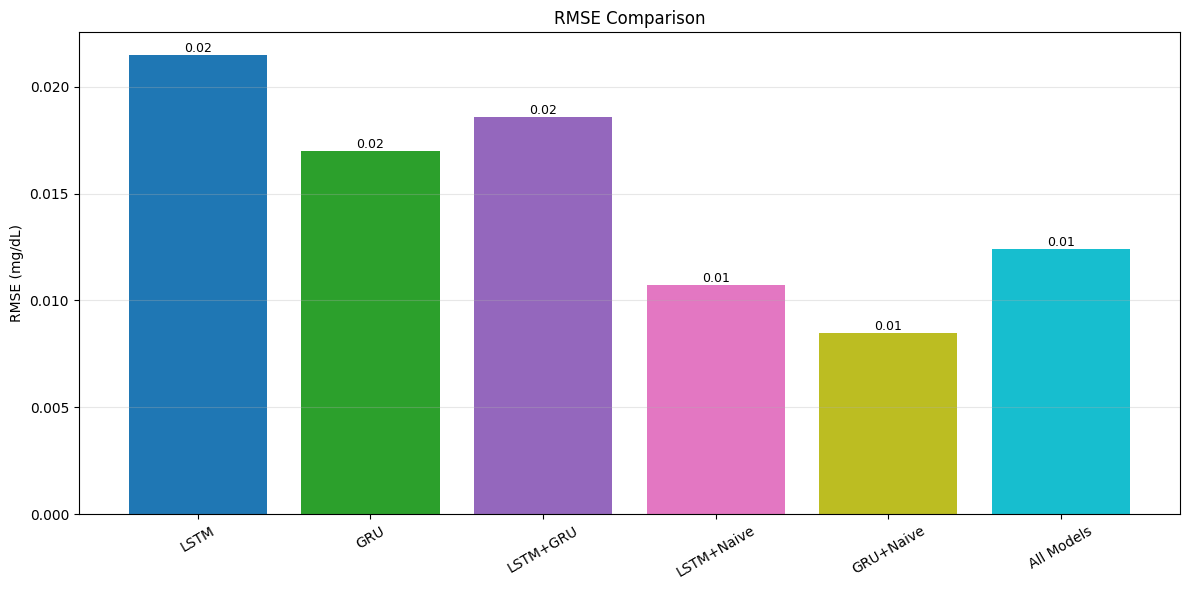

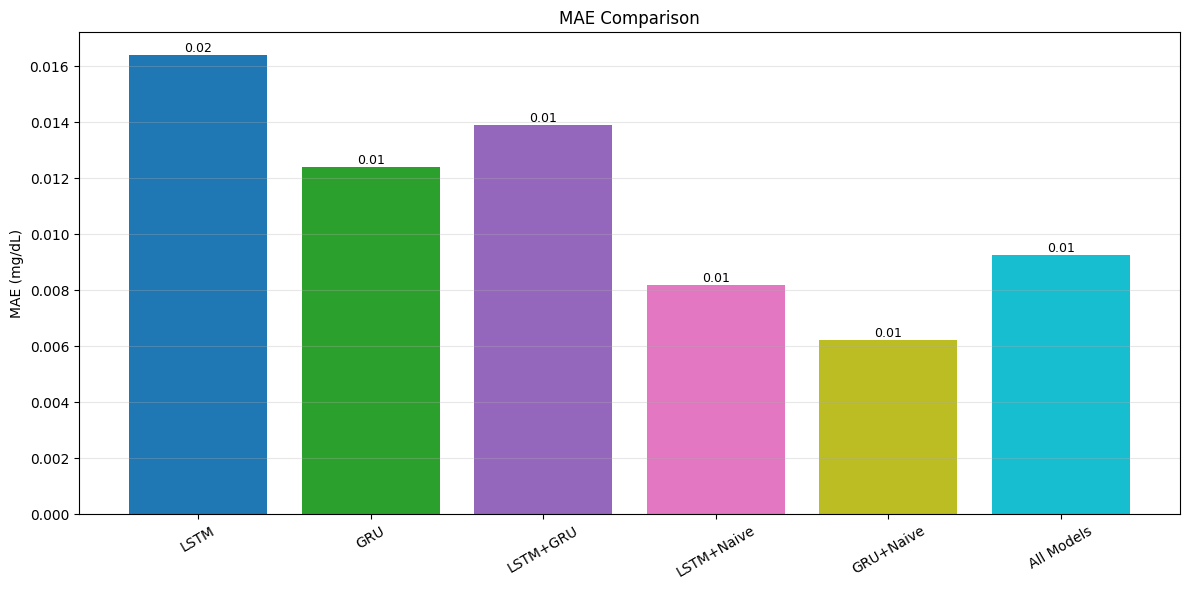

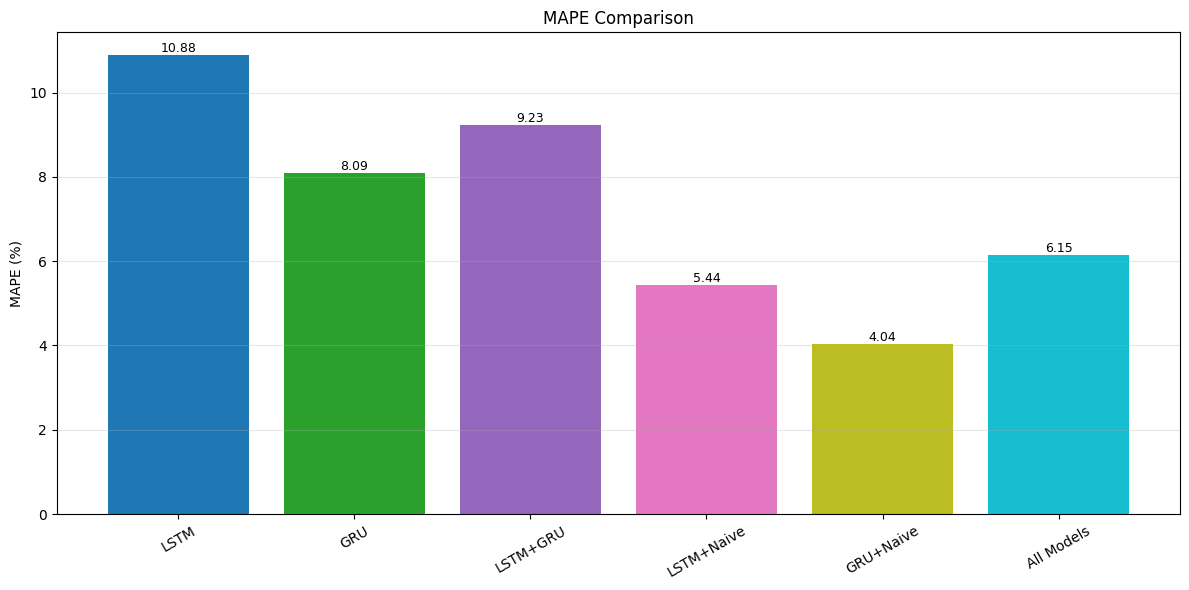

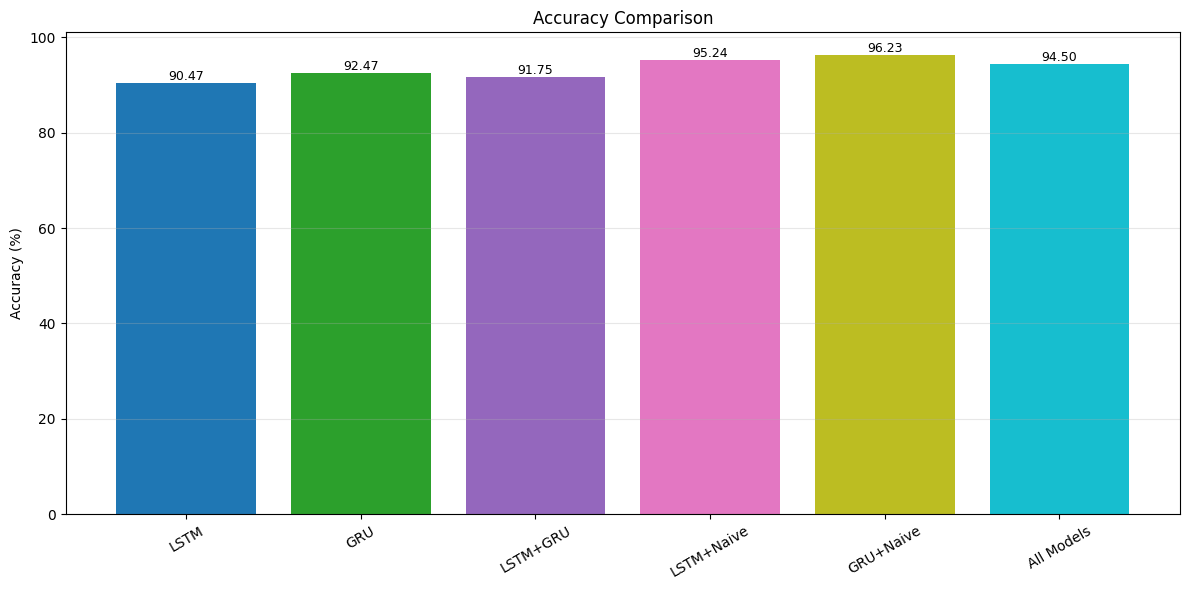

In [70]:
plot_metric_colored(performance_df, "RMSE (mg/dL)", "RMSE (mg/dL)", "RMSE Comparison")
plot_metric_colored(performance_df, "MAE (mg/dL)", "MAE (mg/dL)", "MAE Comparison")
plot_metric_colored(performance_df, "MAPE (%)", "MAPE (%)", "MAPE Comparison")
plot_metric_colored(
    performance_df,
    "Accuracy ±10 mg/dL (%)",
    "Accuracy (%)",
    "Accuracy Comparison"
)


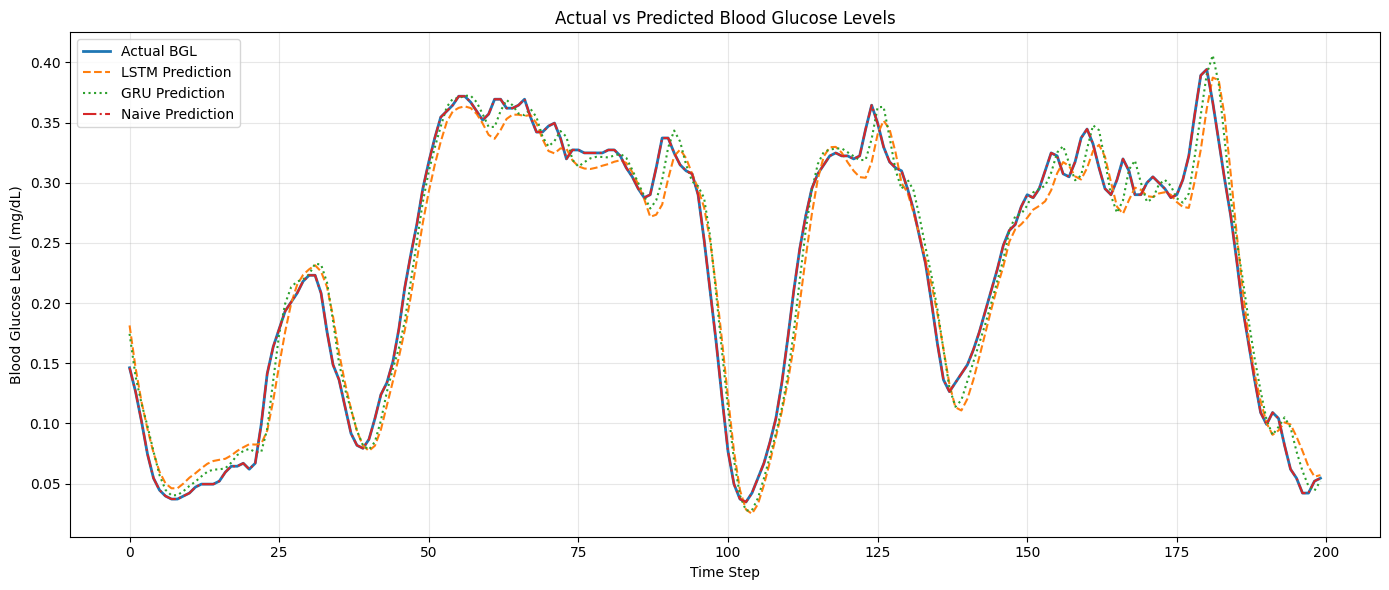

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Select a window to visualize (avoid overcrowding)
N = 200   # number of time steps to plot

time_steps = np.arange(N)

plt.figure(figsize=(14,6))

plt.plot(
    time_steps,
    y_true[:N],
    label="Actual BGL",
    linewidth=2
)

plt.plot(
    time_steps,
    lstm_preds[:N],
    label="LSTM Prediction",
    linestyle="--"
)

plt.plot(
    time_steps,
    gru_preds[:N],
    label="GRU Prediction",
    linestyle=":"
)

plt.plot(
    time_steps,
    naive_preds[:N],
    label="Naive Prediction",
    linestyle="-."
)

plt.xlabel("Time Step")
plt.ylabel("Blood Glucose Level (mg/dL)")
plt.title("Actual vs Predicted Blood Glucose Levels")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
